# Wavelet Transform implementation

In this notebook I will test the implementation of wavelet transform with diff families of wavelets : Daubechies, Biorthogonal, Symbols

In [ ]:
from Wavelet import WaveletLoss  # assuming your file is named wavelet_loss.py
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pywt
# import overlay text 
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Test Dummy Input 

In [19]:
# Dummy 2D input
pred = torch.randn(2, 1, 64, 64)
target = torch.randn(2, 1, 64, 64)

# Wavelet Loss

In [24]:
# sanity check : 
lossSelf = WaveletLoss(wavelet='haar', levels=2, loss_type='l1')
loss_self=lossSelf(pred,pred)
print("Check for sanity\nWavelet loss (identity):", loss_self.item())  # Should be close to 0

# Initialize the loss

criterion = WaveletLoss(wavelet='db4', levels=2, loss_type='l1')
criterionn= WaveletLoss(wavelet='haar', levels=2, loss_type='l1')  # Initialize the loss function

# Compute the loss
WLoss_db4 = criterion(pred, target)
print(f"Wavelet loss: {WLoss_db4.item():.6f}")

WLoss_haar=criterionn(pred, target)
print(f"Wavelet loss: {WLoss_haar.item():.6f}")



Check for sanity
Wavelet loss (identity): 0.0
Wavelet loss: 7.549285
Wavelet loss: 7.355337


# MAE

In [10]:
mae=nn.L1Loss()
mae_loss=mae(pred,target)
print(f"MAE loss: {mae_loss.item():.6f}")

MAE loss: 1.117229


# Wavelet Decomposition 

###

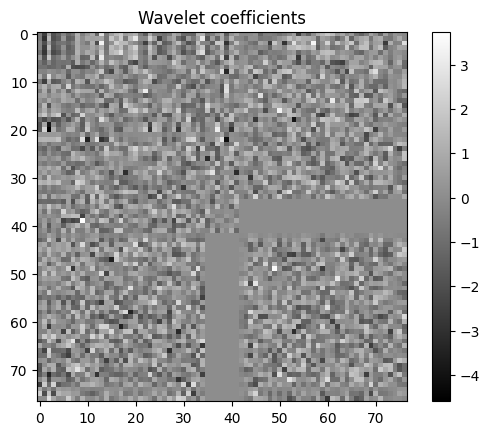

In [ ]:

image = pred[0, 0].detach().numpy()  # Take one image
coeffs = pywt.wavedec2(image, wavelet='db4', level=2)
arr, _ = pywt.coeffs_to_array(coeffs)

plt.imshow(arr, cmap='gray')
plt.title("Wavelet coefficients")
plt.colorbar()
plt.show()


## Load Data

In [80]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Load the NIfTI file
mri_3T = nib.load('/home/nbelloula/GAI/Synthetic7TMRI4/data/original/3T/sub-MS3T001_T1w_MNI152_ANTs.nii.gz')
mri_7T = nib.load('/home/nbelloula/GAI/Synthetic7TMRI4/data/original/7T/sub-MS7T001_T1w_MNI152_ANTs.nii.gz')

mri_7T_synthetic_pretrained = nib.load('/home/nbelloula/GAI/Synthetic7TMRI4/data/Synthetic/7T_synth_VNet_pretrained/sub-MS3T001_T1w_MNI152_ANTs_pred.nii.gz')    
mri_7T_synthetic_costumfold = nib.load('/home/nbelloula/GAI/Synthetic7TMRI4/data/Synthetic/7T_synth_VNet_V0_finalmodel_250epochs/sub-MS3T001_T1w_MNI152_ANTs_pred.nii.gz')

img_3T = mri_3T.get_fdata() # shape: (H, W, D) or (H, W) for 2D images

# select the middle slice of axial view if 3D
def select_middle_slice(img):
    if img.ndim == 3:
        return img[:, :, img.shape[2] // 2]  # shape: (H, W)
    elif img.ndim == 2:
        return img  # already 2D
    else:
        raise ValueError("Input image must be 2D or 3D.")   
    
img3T = select_middle_slice(img_3T)  
img7T = select_middle_slice(mri_7T.get_fdata()) 

# Normalize image to [0, 1] for visualization
#img = (img - img.min()) / (img.max() - img.min() + 1e-8)




In [85]:
# Perform wavelet decomposition db4 
## db4 is Daubechies wavelet with 4 vanishing moments
coeffs_db4_l1 = pywt.wavedec2(img3T, wavelet='db4', level=1)
arr_db4_l1, _ = pywt.coeffs_to_array(coeffs_db4_l1)

coeffs_db4_l1_7t= pywt.wavedec2(img7T, wavelet='db4', level=1)
arr_db4_l1_7t, _ = pywt.coeffs_to_array(coeffs_db4_l1_7t)

coeffs_db4_l2= pywt.wavedec2(img3T, wavelet='db4', level=2)
arr_db4_l2, _ = pywt.coeffs_to_array(coeffs_db4_l2)

coeffs_db4_l3 = pywt.wavedec2(img3T, wavelet='db4', level=3)
arr_db4_l3, _ = pywt.coeffs_to_array(coeffs_db4_l3)

# sym5 
coeffs_sym5_l1 = pywt.wavedec2(img3T, wavelet='sym5', level=1)
arr_sym5_l1, _ = pywt.coeffs_to_array(coeffs_sym5_l1)

coeffs_sym5_l1_7t = pywt.wavedec2(img7T, wavelet='sym5', level=1)
arr_sym5_l1_7t, _ = pywt.coeffs_to_array(coeffs_sym5_l1_7t)

coeffs_sym5_l2 = pywt.wavedec2(img3T, wavelet='sym5', level=2)
arr_sym5_l2, _ = pywt.coeffs_to_array(coeffs_sym5_l2)   

coeffs_sym5_l3 = pywt.wavedec2(img3T, wavelet='sym5', level=3)
arr_sym5_l3, _ = pywt.coeffs_to_array(coeffs_sym5_l3)

coeffs_sym3_l1 = pywt.wavedec2(img3T, wavelet='sym3', level=2)
arr_sym3_l1, _ = pywt.coeffs_to_array(coeffs_sym5_l1)

#sym8
# coeffs_sym8_l1 = pywt.wavedec2(img3T, wavelet='sym8', level=1)
# arr_sym8_l1, _ = pywt.coeffs_to_array(coeffs_sym8_l1)

# coeffs_sym5_l2 = pywt.wavedec2(img3T, wavelet='sym5', level=2)
# arr_sym5_l2, _ = pywt.coeffs_to_array(coeffs_sym5_l2)

# biorthogonal wavelet  
# 3 T 
coeffs_bior_l1 = pywt.wavedec2(img3T, wavelet='bior4.4', level=1)
arr_bior_l1, _ = pywt.coeffs_to_array(coeffs_bior_l1)

coeffs_bior_l2 = pywt.wavedec2(img3T, wavelet='bior4.4', level=2)
arr_bior_l2, _ = pywt.coeffs_to_array(coeffs_bior_l2)

coeffs_bior_l3 = pywt.wavedec2(img3T, wavelet='bior4.4', level=3)
arr_bior_l3, _ = pywt.coeffs_to_array(coeffs_bior_l3)   

# 7 T 
coeffs_bior_l1_7t = pywt.wavedec2(img7T, wavelet='bior4.4', level=1)
arr_bior_l1_7t, _ = pywt.coeffs_to_array(coeffs_bior_l1_7t)


## Visualization 

### DB

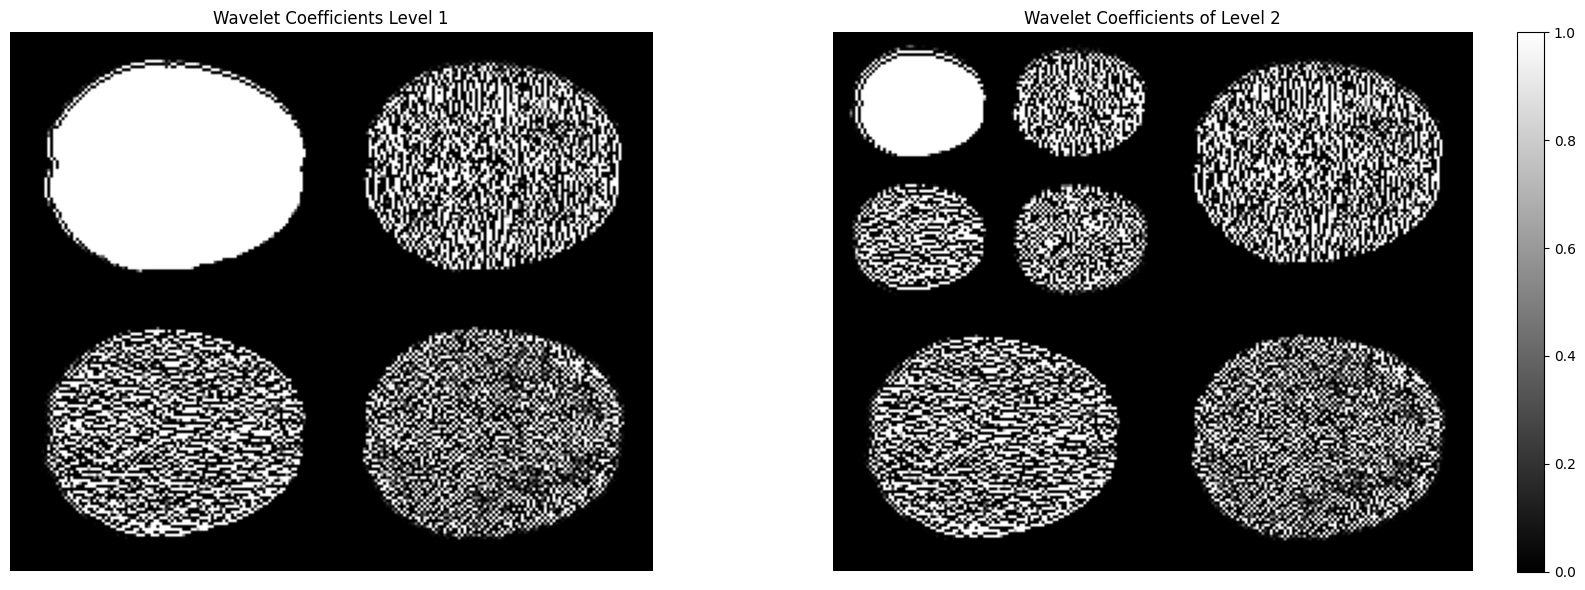

In [78]:
# Plot wavelet coefficient array of two levels of db4 
#using subplot 
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
# plt.imshow(arr_db4_l1, cmap='gray')
plt.imshow(arr_db4_l1, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients Level 1")
plt.axis('off')
plt.subplot(1, 2, 2)
# plt.imshow(arr_db4_l2, cmap='gray')
plt.imshow(arr_db4_l2, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients of Level 2")
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

### Visualize Db4 l1 decomposition for 3t and 7t 

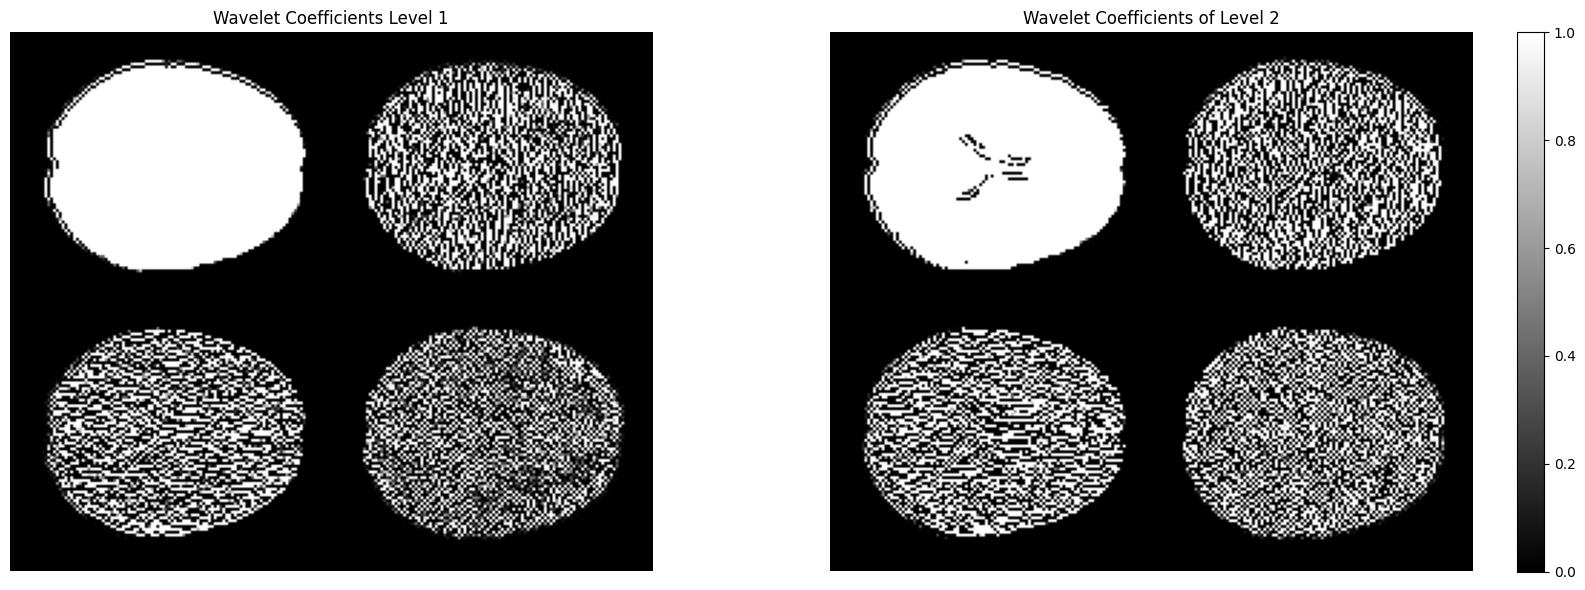

In [84]:
# Plot wavelet coefficient array of two levels of db4 
#using subplot 
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
# plt.imshow(arr_db4_l1, cmap='gray')
plt.imshow(arr_db4_l1, cmap='gray', vmin=0, vmax=1)
#plt.imshow(arr_db4_l1, cmap='gray')
plt.title("Wavelet Coefficients Level 1")
plt.axis('off')
plt.subplot(1, 2, 2)
# plt.imshow(arr_db4_l2, cmap='gray')
plt.imshow(arr_db4_l1_7t, cmap='gray', vmin=0, vmax=1)
#plt.imshow(arr_db4_l1_7t, cmap='gray')
plt.title("Wavelet Coefficients of Level 2")
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

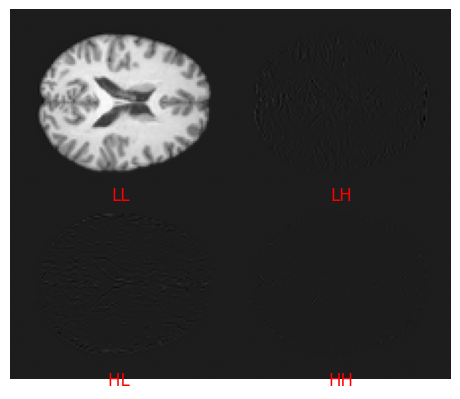

In [ ]:
ig, ax = plt.subplots()
plot_img = arr_db4_l1 # Use arr1 for the first level of decomposition
ax.imshow(plot_img, cmap='gray')



# Get dimensions of the image to label
height, width = plot_img.shape

# Add labels to each quarter 

ax.text(width * 0.25, height * 0.5, 'LL', color='red', fontsize=12, ha='center', va='center')
ax.text(width * 0.75, height * 0.5, 'LH', color='red', fontsize=12, ha='center', va='center')
ax.text(width * 0.25, height, 'HL ', color='red', fontsize=12, ha='center', va='center')
ax.text(width * 0.75, height, 'HH', color='red', fontsize=12, ha='center', va='center')

# Save or show the result
plt.savefig('labeled_image.png', bbox_inches='tight', dpi=300)
plt.show()


### Bior

### Visualize Biorthogonal wave decomp 

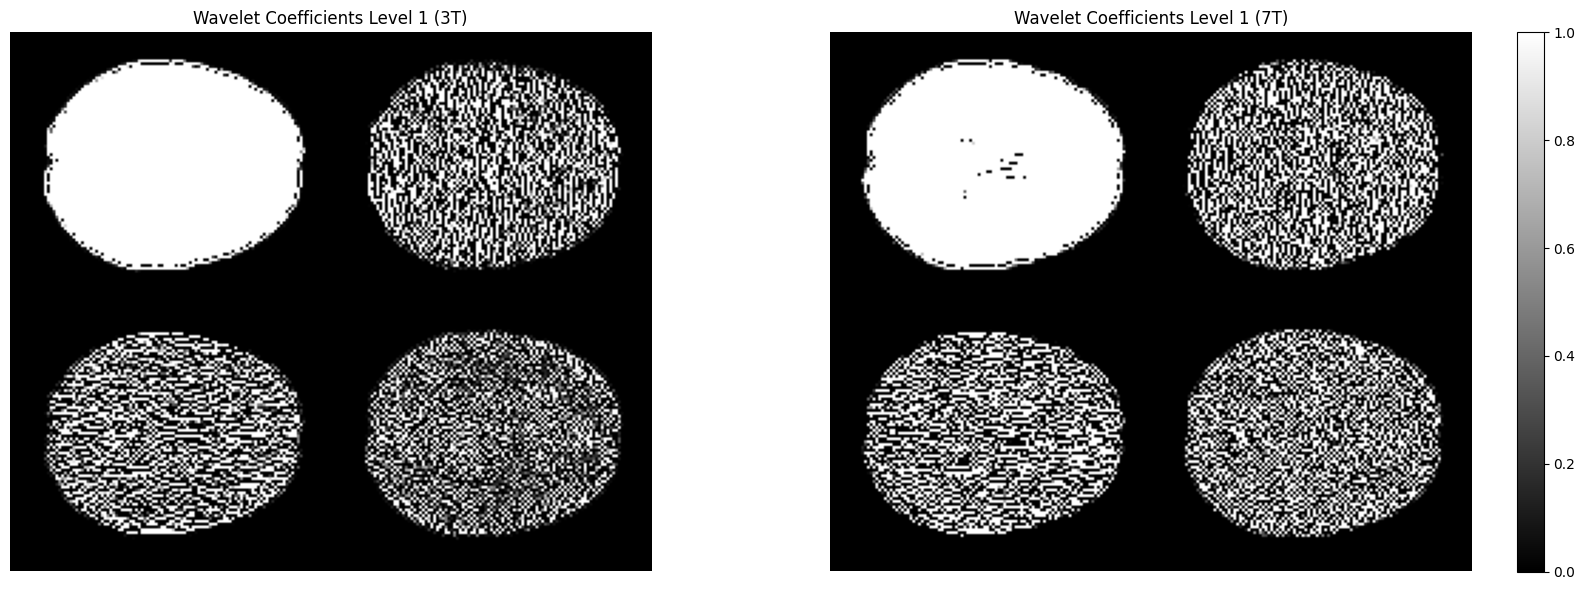

In [ ]:
# Plot wavelet coefficient array of two levels of  bior4.4 for 3t and 7t
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.imshow(arr_bior_l1, cmap='gray', vmin=0, vmax=1)
# plt.imshow(arr_bior_l1, cmap='gray')
plt.title("Wavelet Coefficients Level 1 (3T)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(arr_bior_l1_7t, cmap='gray', vmin=0, vmax=1)
# plt.imshow(arr_bior_l1_7t, cmap='gray')
plt.title("Wavelet Coefficients Level 1 (7T)")
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

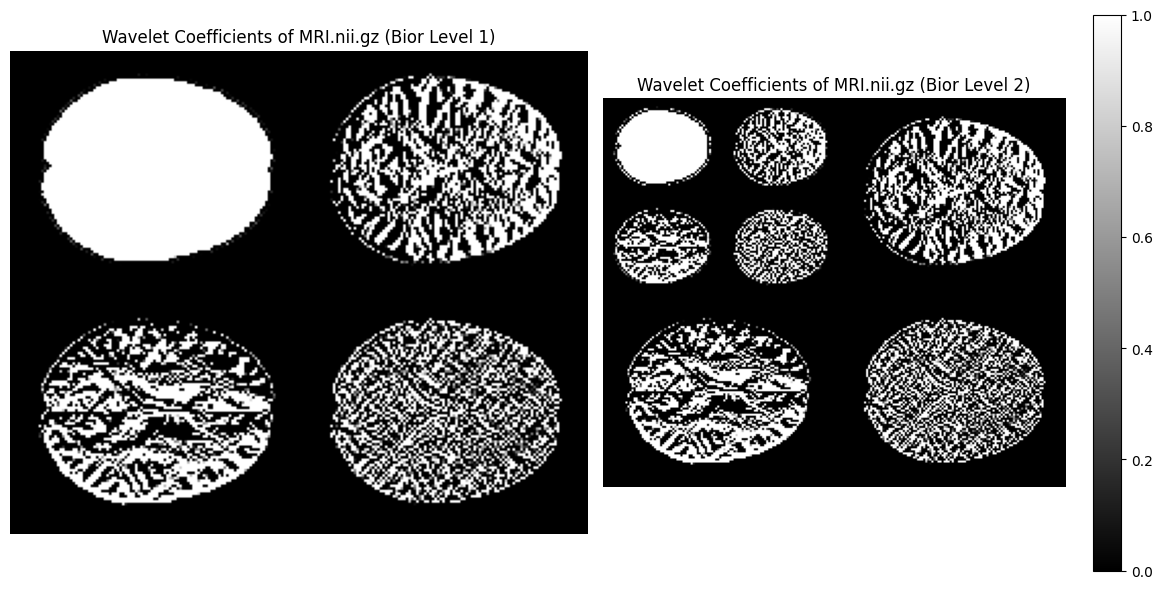

In [45]:
# Plot wavelet coefficient array of two levels of bior
#using subplot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(arr_bior_l1, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients of MRI.nii.gz (Bior Level 1)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(arr_bior_l2, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients of MRI.nii.gz (Bior Level 2)")
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

### Sym

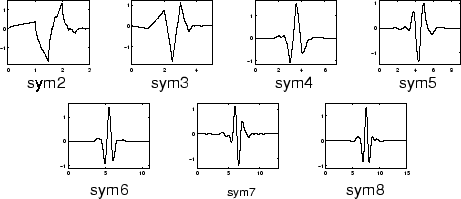

From https://fr.mathworks.com/help/wavelet/gs/introduction-to-the-wavelet-families.html

###  Sym5 3 T vs 7 T 

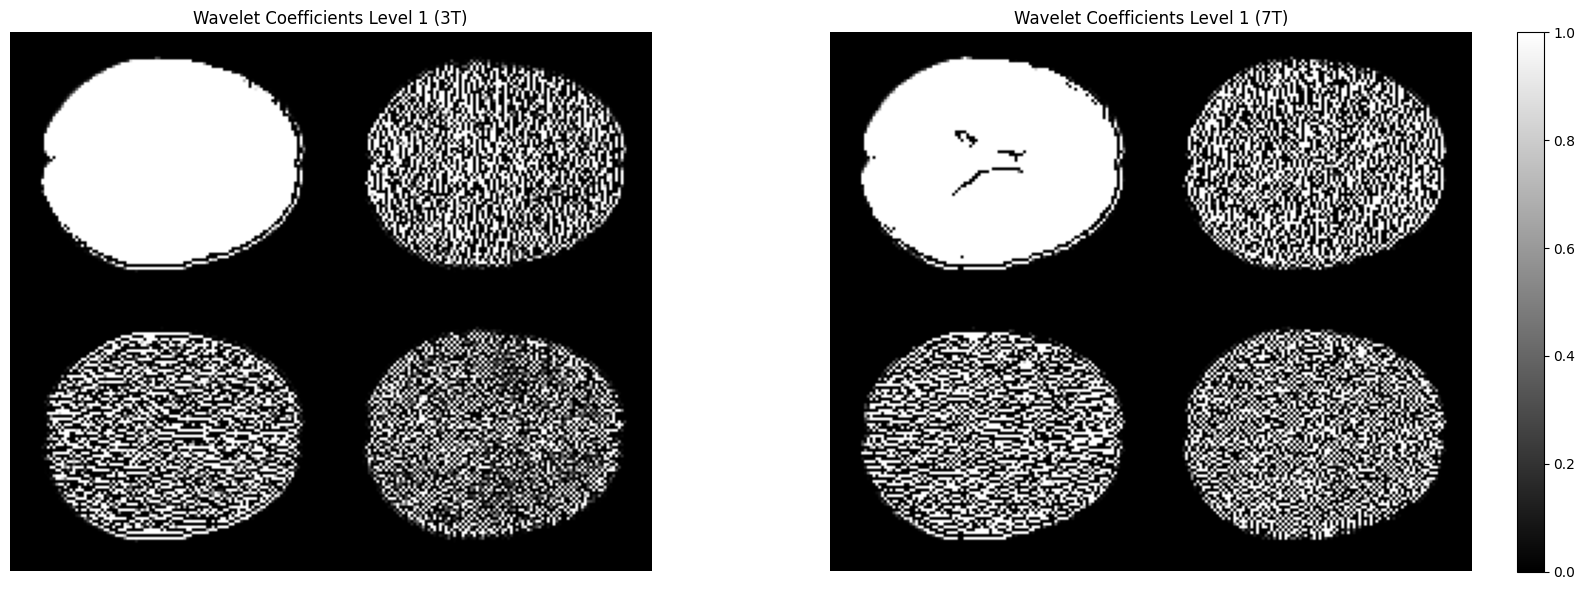

In [87]:
# Plot wavelet coefficient array of 3 t vs 7 t sym5
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.imshow(arr_sym5_l1, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients Level 1 (3T)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(arr_sym5_l1_7t, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients Level 1 (7T)")
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

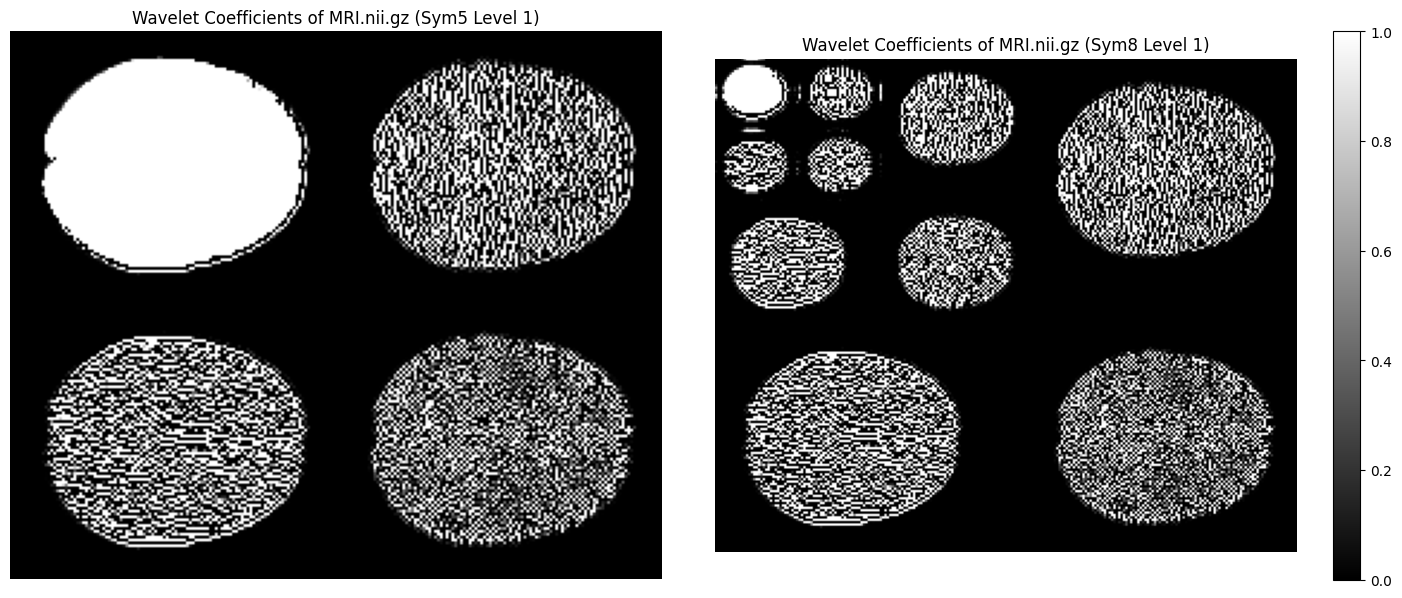

In [68]:
# Plot wavelet coefficient array of two levels of sym5
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(arr_sym5_l1, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients of MRI.nii.gz (Sym5 Level 1)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(arr_sym5_l3, cmap='gray', vmin=0, vmax=1)
plt.title("Wavelet Coefficients of MRI.nii.gz (Sym8 Level 1)")
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

# SSIM 3T vs 7T & respective D components

In [88]:
# calculate SSIM for 3T vs 7T
from skimage.metrics import structural_similarity as ssim
def calculate_ssim(img1, img2):
    """Calculate SSIM between two images."""
    return ssim(img1, img2, data_range=img1.max() - img1.min()) 

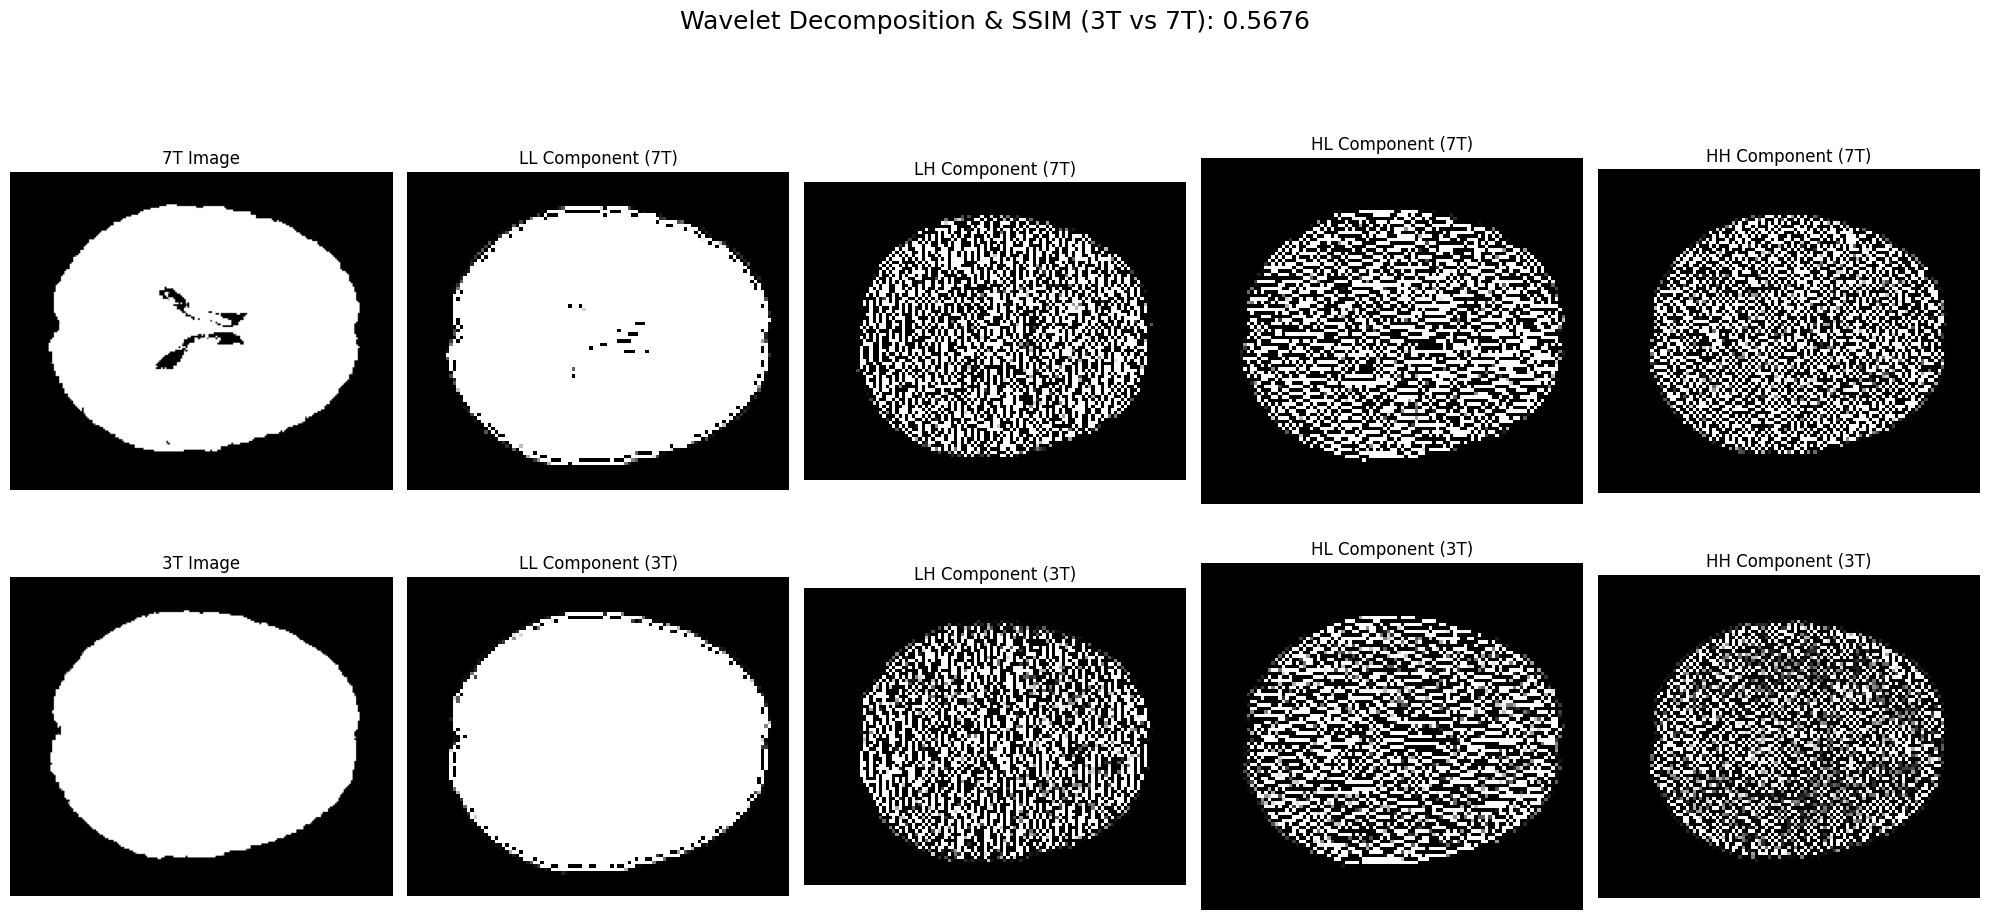

In [ ]:
ssim_3T_7T = calculate_ssim(img3T, img7T)

# extract LL, LH, HL, HH components from the wavelet decomposition as images 
ll_3T = arr_bior_l1[0:img3T.shape[0]//2, 0:img3T.shape[1]//2]
lh_3T = arr_bior_l1[0:img3T.shape[0]//2, img3T.shape[1]//2:]
hl_3T = arr_bior_l1[img3T.shape[0]//2:, 0:img3T.shape[1]//2]
hh_3T = arr_bior_l1[img3T.shape[0]//2:, img3T.shape[1]//2:]

# extract LL, LH, HL, HH components from the wavelet decomposition as images for 7T
ll_7T = arr_bior_l1_7t[0:img7T.shape[0]//2, 0:img7T.shape[1]//2]        
lh_7T = arr_bior_l1_7t[0:img7T.shape[0]//2, img7T.shape[1]//2:]
hl_7T = arr_bior_l1_7t[img7T.shape[0]//2:, 0:img7T.shape[1]//2]
hh_7T = arr_bior_l1_7t[img7T.shape[0]//2:, img7T.shape[1]//2:]


# Create a single figure with 2 rows and 5 columns
fig, axs = plt.subplots(2, 5, figsize=(20, 10))  # Wider and taller figure

# --- Row 1: 7T decomposition and LL diff ---
axs[0, 0].imshow(img7T, cmap='gray', vmin=0, vmax=1)
axs[0, 0].set_title("7T Image")
axs[0, 0].axis('off')

axs[0, 1].imshow(ll_7T, cmap='gray', vmin=0, vmax=1)
axs[0, 1].set_title("LL Component (7T)")
axs[0, 1].axis('off')

axs[0, 2].imshow(lh_7T, cmap='gray', vmin=0, vmax=1)
axs[0, 2].set_title("LH Component (7T)")
axs[0, 2].axis('off')

axs[0, 3].imshow(hl_7T, cmap='gray', vmin=0, vmax=1)
axs[0, 3].set_title("HL Component (7T)")
axs[0, 3].axis('off')

axs[0, 4].imshow(hh_7T, cmap='gray', vmin=0, vmax=1)
axs[0, 4].set_title("HH Component (7T)")
axs[0, 4].axis('off')

# --- Row 2: 3T decomposition ---
axs[1, 0].imshow(img3T, cmap='gray', vmin=0, vmax=1)
axs[1, 0].set_title("3T Image")
axs[1, 0].axis('off')

axs[1, 1].imshow(ll_3T, cmap='gray', vmin=0, vmax=1)
axs[1, 1].set_title("LL Component (3T)")
axs[1, 1].axis('off')

axs[1, 2].imshow(lh_3T, cmap='gray', vmin=0, vmax=1)
axs[1, 2].set_title("LH Component (3T)")
axs[1, 2].axis('off')

axs[1, 3].imshow(hl_3T, cmap='gray', vmin=0, vmax=1)
axs[1, 3].set_title("HL Component (3T)")
axs[1, 3].axis('off')

axs[1, 4].imshow(hh_3T, cmap='gray', vmin=0, vmax=1)
axs[1, 4].set_title("HH Component (3T)")
axs[1, 4].axis('off')

# Add a single super title for the whole figure
fig.suptitle(f"Wavelet Decomposition & SSIM (3T vs 7T): {ssim_3T_7T:.4f}", fontsize=18)

# Adjust layout to avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.show()


In [ ]:
# calculate SSIM for 3T vs 7T
from skimage.metrics import structural_similarity as ssim
def calculate_ssim(img1, img2):
    """Calculate SSIM between two images."""
    return ssim(img1, img2, data_range=img1.max() - img1.min())
    

In [114]:
# calculate SSIM between 3T and 7T images
ssim_3T_7T = calculate_ssim(img3T, img7T) 
print("SSIM between 3T and 7T images:", ssim_3T_7T)

#calculate SSIM between 3T and 7T WD components
ssim_ll_3T_7T = calculate_ssim(ll_3T, ll_7T)
print("SSIM LL (3T vs 7T):", ssim_ll_3T_7T)

ssim_lh_3T_7T = calculate_ssim(lh_3T, lh_7T)
print("SSIM LH (3T vs 7T):", ssim_lh_3T_7T)

ssim_hl_3T_7T = calculate_ssim(hl_3T, hl_7T)
print("SSIM HL (3T vs 7T):", ssim_hl_3T_7T)

ssim_hh_3T_7T = calculate_ssim(hh_3T, hh_7T)
print("SSIM HH (3T vs 7T):", ssim_hh_3T_7T)


# use table format to display SSIM results without index
import pandas as pd
ssim_results = {
    "Component": ["LL", "LH", "HL", "HH"],
    "SSIM (3T vs 7T)": [ssim_ll_3T_7T, ssim_lh_3T_7T, ssim_hl_3T_7T, ssim_hh_3T_7T]
}
ssim_df = pd.DataFrame(ssim_results)
print(ssim_df)  

SSIM between 3T and 7T images: 0.5675908027682566
SSIM LL (3T vs 7T): 0.5163196772637588
SSIM LH (3T vs 7T): 0.4167291851916231
SSIM HL (3T vs 7T): 0.40581633508681464
SSIM HH (3T vs 7T): 0.44162546474819075
  Component  SSIM (3T vs 7T)
0        LL         0.516320
1        LH         0.416729
2        HL         0.405816
3        HH         0.441625


### Image reconstruction 

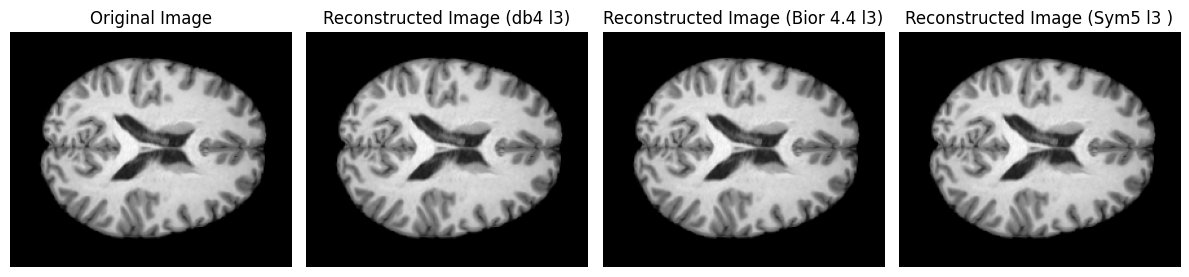

In [ ]:
# Image reconstruction from wavelet coefficients
reconstructed_db4_l1 = pywt.waverec2(coeffs_db4_l1, wavelet='db4')
reconstructed_bior_l1 = pywt.waverec2(coeffs_bior_l1, wavelet='bior1.3')
reconstructed_sym5_l1 = pywt.waverec2(coeffs_sym5_l1, wavelet='sym5')

reconstructed_db4_l3 = pywt.waverec2(coeffs_db4_l3, wavelet='db4')
reconstructed_bior_l3 = pywt.waverec2(coeffs_bior_l3, wavelet='bior4.4')
reconstructed_sym5_l3 = pywt.waverec2(coeffs_sym5_l3, wavelet='sym5')


# display the original and reconstructed images
plt.figure(figsize=(12, 24))
plt.subplot(1, 4 , 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(reconstructed_db4_l3, cmap='gray')
plt.title("Reconstructed Image (db4 l3)")
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(reconstructed_bior_l3, cmap='gray')
plt.title("Reconstructed Image (Bior 4.4 l3)")
plt.axis('off')
plt.subplot(1,4,4)
plt.imshow(reconstructed_sym5_l3, cmap='gray')
plt.title("Reconstructed Image (Sym5 l3 )")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# # calculate SSIM between original and reconstructed images
# from skimage.metrics import structural_similarity as ssim

# # if img normalized, use np.clip [0,1]
# ssim_db4 = ssim(img, reconstructed_db4_l3, data_range=reconstructed_db4_l3.max() - reconstructed_db4_l3.min())
# ssim_bior = ssim(img, reconstructed_bior_l3, data_range=reconstructed_bior_l3.max() - reconstructed_bior_l3.min())
# ssim_sym5 = ssim(img, reconstructed_sym5_l3, data_range=reconstructed_sym5_l3.max() - reconstructed_sym5_l3.min())


# print(f"SSIM (db4): {ssim_db4:.4f}")
# print(f"SSIM (bior): {ssim_bior:.4f}")      
# print(f"SSIM (sym5): {ssim_sym5:.4f}")

SSIM (db4): 1.0000
SSIM (bior): 1.0000
SSIM (sym5): 1.0000
